创建输出目录: gmm_output/
                    Gaussian Mixture Model (GMM)

[Step 1] Generating cluster data...
Generated: 600 samples, 4 clusters
Data shape: (600, 2)

[Step 2] Training Gaussian Mixture Model...
----------------------------------------------------------------------
Iteration   0: Log-Likelihood = -3047.8992
Iteration  10: Log-Likelihood = -2529.4888
Iteration  20: Log-Likelihood = -2526.5980
Iteration  30: Log-Likelihood = -2526.5367

收敛于第 36 次迭代
最终对数似然: -2526.5354

[Step 3] Predicting cluster labels...

Predicted labels shape: (600,)
Probability matrix shape: (600, 4)

Samples per cluster:
  Cluster 0: 150 samples (25.0%)
  Cluster 1: 162 samples (27.0%)
  Cluster 2: 151 samples (25.2%)
  Cluster 3: 137 samples (22.8%)

[Step 4] Evaluating clustering performance...

Clustering Evaluation Metrics:
Adjusted Rand Index (ARI): 0.8685
Normalized Mutual Info (NMI): 0.8729

[Step 5] Visualizing results...
已保存: gmm_output\gmm_results.png


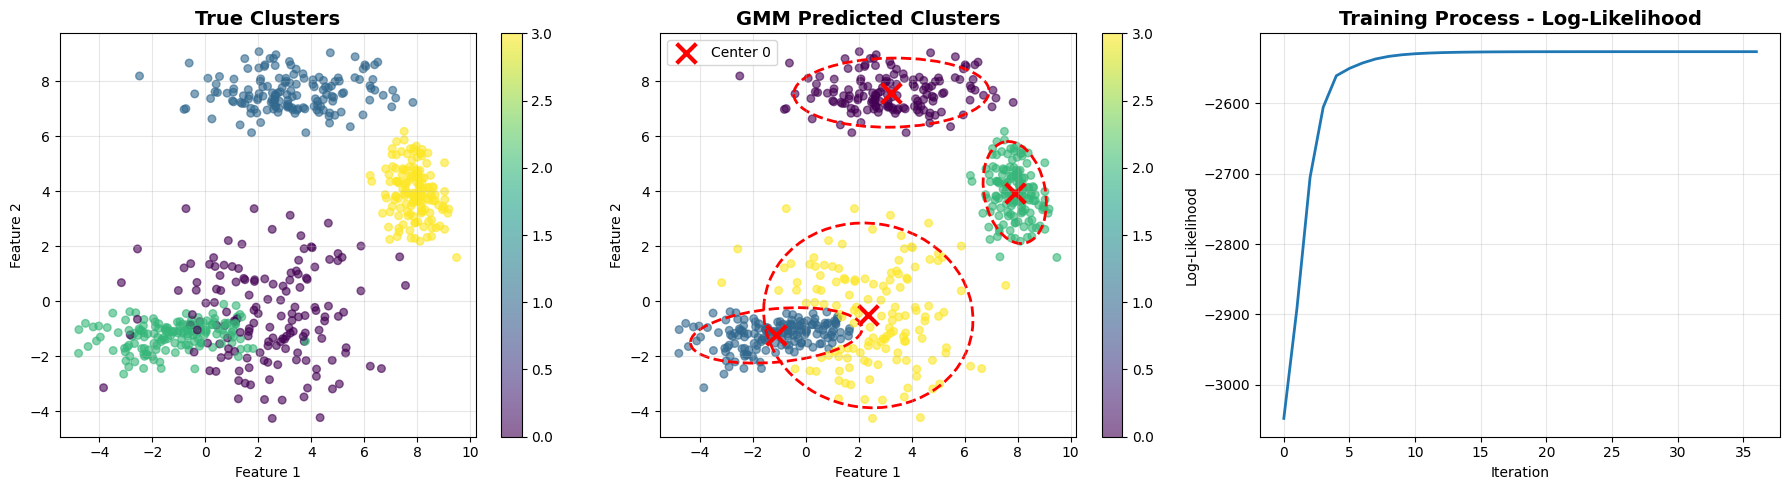

已保存: gmm_output\gmm_probability.png


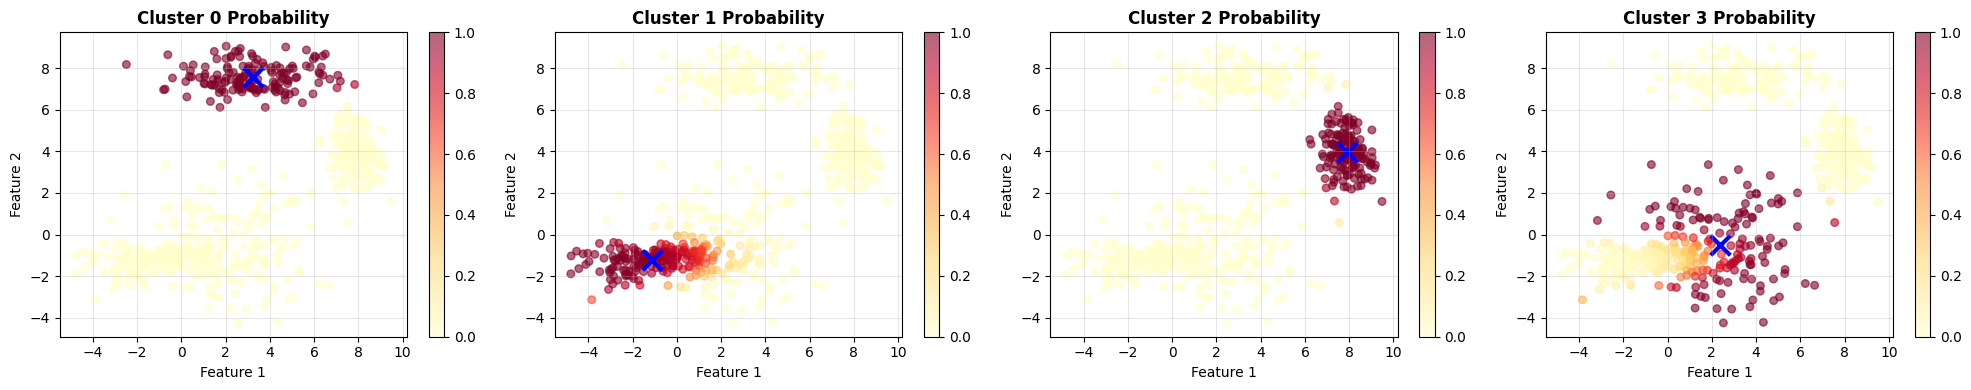


[Step 6] Model parameters:
----------------------------------------------------------------------
Mixing coefficients (pi):
[0.24975022 0.2574536  0.25146967 0.24132649]

Means (mu):
[[ 3.23604038  7.57929726]
 [-1.10853605 -1.23846406]
 [ 7.89030334  3.95220734]
 [ 2.36382542 -0.51121233]]

Covariance determinants (distribution size):
  Cluster 0: 1.3365
  Cluster 1: 0.6226
  Cluster 2: 0.2932
  Cluster 3: 10.9590

Training complete! Results saved to gmm_output/


In [6]:
"""
高斯混合模型 (GMM) - 跨平台版本
支持 Windows / Linux / macOS

使用EM算法进行无监督聚类
纯NumPy实现，无深度学习框架
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import os

# 设置随机种子保证可复现性
np.random.seed(42)

# 创建输出目录（如果不存在）
OUTPUT_DIR = "gmm_output"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"创建输出目录: {OUTPUT_DIR}/")


# ================================
# 1. 数据生成
# ================================

def generate_cluster_data(n_samples=300, n_clusters=3, n_features=2, cluster_std=1.0):
    """
    生成多个高斯分布的聚类数据
    """
    samples_per_cluster = n_samples // n_clusters
    
    # 随机生成聚类中心
    centers = np.random.randn(n_clusters, n_features) * 5
    
    X = []
    y_true = []
    
    for i in range(n_clusters):
        # 为每个聚类生成不同的协方差矩阵
        angle = np.random.rand() * 2 * np.pi
        rotation = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle), np.cos(angle)]
        ])
        
        scales = np.random.rand(n_features) * cluster_std + 0.5
        cov = rotation @ np.diag(scales ** 2) @ rotation.T
        
        samples = np.random.multivariate_normal(centers[i], cov, samples_per_cluster)
        
        X.append(samples)
        y_true.extend([i] * samples_per_cluster)
    
    X = np.vstack(X)
    y_true = np.array(y_true)
    
    # 打乱数据
    indices = np.random.permutation(len(X))
    X = X[indices]
    y_true = y_true[indices]
    
    return X, y_true


# ================================
# 2. 高斯混合模型类
# ================================

class GaussianMixtureModel:
    """高斯混合模型 (GMM) - 使用EM算法"""
    
    def __init__(self, n_components=3, max_iter=100, tol=1e-4, reg_covar=1e-6):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        
        # 模型参数
        self.weights = None
        self.means = None
        self.covariances = None
        
        # 训练历史
        self.log_likelihoods = []
    
    def _initialize_parameters(self, X):
        """初始化模型参数 - 使用K-means++"""
        n_samples, n_features = X.shape
        
        # 1. 混合系数(均匀分布)
        self.weights = np.ones(self.n_components) / self.n_components
        
        # 2. K-means++初始化均值
        centers_idx = [np.random.randint(n_samples)]
        
        for _ in range(1, self.n_components):
            distances = np.min([
                np.sum((X - X[idx]) ** 2, axis=1) 
                for idx in centers_idx
            ], axis=0)
            
            probs = distances / distances.sum()
            next_idx = np.random.choice(n_samples, p=probs)
            centers_idx.append(next_idx)
        
        self.means = X[centers_idx]
        
        # 3. 初始化协方差矩阵
        global_cov = np.cov(X.T) + self.reg_covar * np.eye(n_features)
        self.covariances = np.array([global_cov] * self.n_components)
    
    def _multivariate_gaussian(self, X, mean, cov):
        """计算多元高斯分布的概率密度"""
        n_features = X.shape[1]
        
        cov = cov + self.reg_covar * np.eye(n_features)
        
        det = np.linalg.det(cov)
        inv_cov = np.linalg.inv(cov)
        
        norm_const = 1.0 / (np.sqrt((2 * np.pi) ** n_features * det))
        
        X_centered = X - mean
        exponent = -0.5 * np.sum(X_centered @ inv_cov * X_centered, axis=1)
        
        return norm_const * np.exp(exponent)
    
    def _e_step(self, X):
        """E步: 计算后验概率(责任度)"""
        n_samples = X.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))
        
        for k in range(self.n_components):
            responsibilities[:, k] = self.weights[k] * self._multivariate_gaussian(
                X, self.means[k], self.covariances[k]
            )
        
        responsibilities /= (responsibilities.sum(axis=1, keepdims=True) + 1e-10)
        
        return responsibilities
    
    def _m_step(self, X, responsibilities):
        """M步: 更新参数"""
        n_samples, n_features = X.shape
        
        N_k = responsibilities.sum(axis=0) + 1e-10
        
        self.weights = N_k / n_samples
        self.means = (responsibilities.T @ X) / N_k[:, np.newaxis]
        
        for k in range(self.n_components):
            X_centered = X - self.means[k]
            weighted_cov = (responsibilities[:, k:k+1] * X_centered).T @ X_centered
            self.covariances[k] = weighted_cov / N_k[k]
            self.covariances[k] += self.reg_covar * np.eye(n_features)
    
    def _compute_log_likelihood(self, X):
        """计算对数似然"""
        log_likelihood = 0.0
        
        for n in range(len(X)):
            likelihood = 0.0
            for k in range(self.n_components):
                prob = self._multivariate_gaussian(
                    X[n:n+1], self.means[k], self.covariances[k]
                )
                # 确保是标量
                if isinstance(prob, np.ndarray):
                    prob = prob[0]
                likelihood += self.weights[k] * prob
            log_likelihood += np.log(likelihood + 1e-10)
        
        return float(log_likelihood)
    
    def fit(self, X, verbose=True):
        """使用EM算法训练GMM"""
        self._initialize_parameters(X)
        
        prev_log_likelihood = -np.inf
        
        for iteration in range(self.max_iter):
            # E步
            responsibilities = self._e_step(X)
            
            # M步
            self._m_step(X, responsibilities)
            
            # 计算对数似然
            log_likelihood = self._compute_log_likelihood(X)
            self.log_likelihoods.append(log_likelihood)
            
            if verbose and iteration % 10 == 0:
                print(f"Iteration {iteration:3d}: Log-Likelihood = {log_likelihood:.4f}")
            
            # 检查收敛
            if abs(log_likelihood - prev_log_likelihood) < self.tol:
                if verbose:
                    print(f"\n收敛于第 {iteration} 次迭代")
                    print(f"最终对数似然: {log_likelihood:.4f}")
                break
            
            prev_log_likelihood = log_likelihood
        else:
            if verbose:
                print(f"\n达到最大迭代次数 {self.max_iter}")
                print(f"最终对数似然: {log_likelihood:.4f}")
        
        return self
    
    def predict(self, X):
        """预测样本所属的聚类"""
        responsibilities = self._e_step(X)
        return np.argmax(responsibilities, axis=1)
    
    def predict_proba(self, X):
        """预测样本属于每个聚类的概率"""
        return self._e_step(X)
    
    def score(self, X):
        """计算模型的对数似然得分"""
        return self._compute_log_likelihood(X)


# ================================
# 3. 可视化函数
# ================================

def plot_gmm_results(X, y_true, gmm, title="GMM Clustering Results"):
    """可视化GMM聚类结果"""
    y_pred = gmm.predict(X)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. 真实标签
    ax = axes[0]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6, s=30)
    ax.set_title('True Clusters', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=ax)
    ax.grid(True, alpha=0.3)
    
    # 2. 预测标签
    ax = axes[1]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6, s=30)
    
    # 绘制高斯分布的等高线
    for k in range(gmm.n_components):
        mean = gmm.means[k]
        cov = gmm.covariances[k]
        
        ax.scatter(mean[0], mean[1], c='red', marker='x', s=200, linewidths=3, 
                  label=f'Center {k}' if k == 0 else '')
        
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * 2 * np.sqrt(eigenvalues)
        
        ellipse = Ellipse(mean, width, height, angle=angle, 
                         fill=False, edgecolor='red', linewidth=2, linestyle='--')
        ax.add_patch(ellipse)
    
    ax.set_title('GMM Predicted Clusters', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    plt.colorbar(scatter, ax=ax)
    ax.grid(True, alpha=0.3)
    
    # 3. 对数似然曲线
    ax = axes[2]
    ax.plot(gmm.log_likelihoods, linewidth=2)
    ax.set_title('Training Process - Log-Likelihood', fontsize=14, fontweight='bold')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-Likelihood')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 保存到当前目录
    save_path = os.path.join(OUTPUT_DIR, 'gmm_results.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"已保存: {save_path}")
    plt.show()


def plot_probability_heatmap(X, gmm):
    """绘制每个聚类的概率热图"""
    proba = gmm.predict_proba(X)
    
    fig, axes = plt.subplots(1, gmm.n_components, figsize=(5 * gmm.n_components, 4))
    
    if gmm.n_components == 1:
        axes = [axes]
    
    for k in range(gmm.n_components):
        ax = axes[k]
        scatter = ax.scatter(X[:, 0], X[:, 1], c=proba[:, k], cmap='YlOrRd', 
                           alpha=0.6, s=30, vmin=0, vmax=1)
        ax.scatter(gmm.means[k, 0], gmm.means[k, 1], c='blue', marker='x', 
                  s=200, linewidths=3)
        ax.set_title(f'Cluster {k} Probability', fontsize=12, fontweight='bold')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        plt.colorbar(scatter, ax=ax)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    save_path = os.path.join(OUTPUT_DIR, 'gmm_probability.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"已保存: {save_path}")
    plt.show()


# ================================
# 4. 评估指标
# ================================

def compute_clustering_metrics(y_true, y_pred):
    """计算聚类评估指标"""
    try:
        from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
        
        ari = adjusted_rand_score(y_true, y_pred)
        nmi = normalized_mutual_info_score(y_true, y_pred)
        
        print("\n" + "="*50)
        print("Clustering Evaluation Metrics:")
        print("="*50)
        print(f"Adjusted Rand Index (ARI): {ari:.4f}")
        print(f"Normalized Mutual Info (NMI): {nmi:.4f}")
        print("="*50)
        
        return ari, nmi
    except ImportError:
        print("\n提示: 安装sklearn可以使用评估指标")
        print("pip install scikit-learn")
        return None, None


# ================================
# 5. 主程序
# ================================

def main():
    """主函数"""
    print("="*70)
    print(" "*20 + "Gaussian Mixture Model (GMM)")
    print("="*70)
    
    # 1. 生成数据
    print("\n[Step 1] Generating cluster data...")
    n_samples = 600
    n_clusters = 4
    X, y_true = generate_cluster_data(
        n_samples=n_samples, 
        n_clusters=n_clusters,
        cluster_std=1.5
    )
    print(f"Generated: {n_samples} samples, {n_clusters} clusters")
    print(f"Data shape: {X.shape}")
    
    # 2. 训练GMM
    print("\n[Step 2] Training Gaussian Mixture Model...")
    print("-"*70)
    gmm = GaussianMixtureModel(
        n_components=n_clusters,
        max_iter=100,
        tol=1e-4
    )
    gmm.fit(X, verbose=True)
    
    # 3. 预测
    print("\n[Step 3] Predicting cluster labels...")
    y_pred = gmm.predict(X)
    proba = gmm.predict_proba(X)
    
    print(f"\nPredicted labels shape: {y_pred.shape}")
    print(f"Probability matrix shape: {proba.shape}")
    print(f"\nSamples per cluster:")
    for k in range(n_clusters):
        count = np.sum(y_pred == k)
        print(f"  Cluster {k}: {count} samples ({count/n_samples*100:.1f}%)")
    
    # 4. 评估
    print("\n[Step 4] Evaluating clustering performance...")
    compute_clustering_metrics(y_true, y_pred)
    
    # 5. 可视化
    print("\n[Step 5] Visualizing results...")
    plot_gmm_results(X, y_true, gmm)
    plot_probability_heatmap(X, gmm)
    
    # 6. 打印学到的参数
    print("\n[Step 6] Model parameters:")
    print("-"*70)
    print("Mixing coefficients (pi):")
    print(gmm.weights)
    print("\nMeans (mu):")
    print(gmm.means)
    print("\nCovariance determinants (distribution size):")
    for k in range(n_clusters):
        det = np.linalg.det(gmm.covariances[k])
        print(f"  Cluster {k}: {det:.4f}")
    
    print("\n" + "="*70)
    print(f"Training complete! Results saved to {OUTPUT_DIR}/")
    print("="*70)


if __name__ == "__main__":
    main()